<a href="https://colab.research.google.com/github/ishaaaan17/Covid-RARS/blob/main/notebooks/11_DNDT_DNDF_RELIABILITY_E2E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Neural Decision Tree (DNDT) and Forest (DNDF) Reliability Study
### Universal Kaggle & Google Colab GPU Runner for COVID-RARS

**Reference Paper:**  
Rofiqul Islam, Nihad Karim Chowdhury, and Muhammad Ashad Kabir. *"Robust COVID-19 detection from cough sounds using deep neural decision tree and forest: A comprehensive cross-datasets evaluation."* Expert Systems with Applications, Vol. 310, 2026, 131235. [DOI: 10.1016/j.eswa.2026.131235](https://doi.org/10.1016/j.eswa.2026.131235)

**Scientific Objective:**  
Evaluate whether differentiable DNDT/DNDF models sustain strong internal discrimination on Coswara respiratory audio across cough, speech, and breath, and test their stability under chronological drift and external transfer to COUGHVID.

## 1. Environment Setup & GPU Check (Works on Kaggle & Colab)

In [1]:
# Install dependencies
%pip install -q torch scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch Version: {torch.__version__}")
print(f"Execution Device: {device}")
if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.11.0+cu128
Execution Device: cuda
GPU Name: NVIDIA L4


## 2. Auto-Detect Environment & Force Sync Latest Code

In [2]:
import os
import sys
from pathlib import Path

# 1. Check if running on Kaggle, Colab, or Workspace
IS_KAGGLE = Path('/kaggle').exists()
IS_COLAB = 'google.colab' in sys.modules or Path('/content').exists()
IS_WORKSPACE = Path('/workspace').exists()

if IS_KAGGLE:
    print("Detected Environment: KAGGLE")
    work_dir = Path('/kaggle/working')
    repo_root = work_dir / 'Covid-RARS'
    if not (repo_root / 'src').exists():
        !git clone https://github.com/ishaaaan17/Covid-RARS.git /kaggle/working/Covid-RARS
    else:
        !git -C /kaggle/working/Covid-RARS fetch origin
        !git -C /kaggle/working/Covid-RARS reset --hard origin/main
    output_dir = work_dir / 'reports/dndf'
elif IS_COLAB:
    print("Detected Environment: GOOGLE COLAB")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    work_dir = Path('/content')
    repo_root = Path('/content/drive/MyDrive/Covid-RARS')
    if not (repo_root / 'src').exists():
        repo_root = work_dir / 'Covid-RARS'
        if not (repo_root / 'src').exists():
            !git clone https://github.com/ishaaaan17/Covid-RARS.git /content/Covid-RARS
        else:
            !git -C /content/Covid-RARS fetch origin
            !git -C /content/Covid-RARS reset --hard origin/main
    output_dir = Path('/content/drive/MyDrive/Covid-RARS/reports/dndf') if Path('/content/drive/MyDrive').exists() else (work_dir / 'reports/dndf')
elif IS_WORKSPACE:
    print("Detected Environment: WORKSPACE")
    repo_root = Path('/workspace/Covid-RARS') if Path('/workspace/Covid-RARS/src').exists() else Path('/workspace')
    output_dir = repo_root / 'reports/dndf'
else:
    print("Detected Environment: LOCAL")
    repo_root = Path('.').resolve()
    output_dir = repo_root / 'reports/dndf'

output_dir.mkdir(parents=True, exist_ok=True)
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))
print(f"Active Repository Root: {repo_root}")
print(f"Output Directory: {output_dir}")

Detected Environment: KAGGLE
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 11 (delta 7), reused 10 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (11/11), 1.29 KiB | 329.00 KiB/s, done.
From https://github.com/ishaaaan17/Covid-RARS
   a5cd730..a1d1954  main       -> origin/main
HEAD is now at a1d1954 Auto-detect external feature columns before launching Track C
Active Repository Root: /kaggle/working/Covid-RARS
Output Directory: /kaggle/working/reports/dndf


In [3]:
from google.colab import drive

drive.mount("/content/drive")


# Create local processed directory
!mkdir -p /content/data/processed


# Copy CSV files from possible Google Drive locations
!cp /content/drive/MyDrive/processed/*.csv /content/data/processed/ 2>/dev/null || true

!cp /content/drive/MyDrive/Covid-RARS/data/processed/*.csv \
    /content/data/processed/ 2>/dev/null || true

!cp /content/drive/MyDrive/*.csv \
    /content/data/processed/ 2>/dev/null || true


# Check what was copied
import os

print(
    "✅ Found files in /content/data/processed:",
    os.listdir("/content/data/processed")
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found files in /content/data/processed: ['features_compare_is10_merged.csv', 'coughvid_metadata_compare_is10_external.csv', 'coughvid_metadata_hst_external.csv', 'metadata_with_quality.csv']


In [4]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Create local processed directory
!mkdir -p /content/data/processed

# 3. Copy the features CSV from Drive to Colab local storage
source = "/content/drive/MyDrive/BTP/processed/features_compare_is10_merged.csv"
destination = "/content/data/processed/features_compare_is10_merged.csv"

if os.path.exists(source):
    !cp "$source" "$destination"
    print(f"✅ Copied: {source}")
else:
    print(f"❌ File not found: {source}")

# 4. Verify
print("\nFiles in /content/data/processed:")
for f in os.listdir("/content/data/processed"):
    print(" 👉", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Copied: /content/drive/MyDrive/BTP/processed/features_compare_is10_merged.csv

Files in /content/data/processed:
 👉 features_compare_is10_merged.csv
 👉 coughvid_metadata_compare_is10_external.csv
 👉 coughvid_metadata_hst_external.csv
 👉 metadata_with_quality.csv


In [5]:
!cp /content/drive/MyDrive/BTP/processed/*.csv /content/data/processed/

import os

print("✅ Ready files:", os.listdir("/content/data/processed"))

✅ Ready files: ['features_compare_is10_merged.csv', 'coughvid_metadata_compare_is10_external.csv', 'coughvid_metadata_hst_external.csv', 'metadata_with_quality.csv']


## 3. Load Engineered Feature Banks (Universal Search across Workspace/Kaggle/Colab/Drive)

In [6]:
from covid_rars.dndf_models import DNDFClassifier, NeuralDecisionTree, NeuralDecisionForest
from covid_rars.dndf_stages import run_dndf_reliability_pipeline
from covid_rars.dndf_reporting import build_dndf_summary_table

def auto_find_file(filenames, base_folders):
    for folder_str in base_folders:
        folder = Path(folder_str)
        if not folder.exists():
            continue
        for root, _, files in os.walk(folder):
            for f in files:
                if f in filenames or any(f.endswith(fn) for fn in filenames):
                    return Path(root) / f
    return None

search_roots = [
    '/workspace/data/processed',
    '/workspace',
    '/content/data/processed',
    '/content/drive/MyDrive',
    '/content',
    '/kaggle/input',
    str(repo_root),
    '.',
    '..',
]

features_path = auto_find_file(
    ['features_compare_is10_merged.csv', 'features_compare_is10_top800.csv'],
    search_roots
)

external_path = auto_find_file(
    ['coughvid_metadata_compare_is10_external.csv', 'features_compare_is10_coughvid_cough_top800.csv'],
    search_roots
)

if features_path is not None:
    print(f"✅ Found features matrix at: {features_path}")
    features_df = pd.read_csv(features_path)
    non_feat = ["participant_id", "recording_id", "modality", "split", "label_binary", "label", "date", "recording_date"]
    feat_cols = [c for c in features_df.columns if c not in non_feat]
    if len(feat_cols) > 800:
        print(f"Detected full feature matrix with {len(feat_cols)} columns. Subsampling top 800 for efficient training.")
        keep_cols = [c for c in non_feat if c in features_df.columns] + feat_cols[:800]
        features_df = features_df[keep_cols].copy()
else:
    print("Notice: Features CSV not found. Generating standardized benchmark frame for demonstration.")
    n_samples = 400
    n_feats = 100
    rng = np.random.RandomState(42)
    records = []
    for i in range(n_samples):
        p_id = f"p_{i:04d}"
        lbl = "positive" if rng.rand() > 0.65 else "negative"
        split = "train" if i < 280 else ("val" if i < 340 else "test")
        for mod in ["cough", "breath", "speech"]:
            row = {"participant_id": p_id, "recording_id": f"{p_id}_{mod}", "label_binary": lbl, "modality": mod, "split": split}
            vec = rng.randn(n_feats) + (1.0 if lbl == "positive" else -0.5)
            for f_idx in range(n_feats):
                row[f"feat_{f_idx:03d}"] = vec[f_idx]
            records.append(row)
    features_df = pd.DataFrame(records)

external_df = pd.read_csv(external_path) if (external_path and external_path.exists()) else None
print(f"📊 Source Features Matrix Shape: {features_df.shape}")
print(f"👥 Total Participants: {features_df['participant_id'].nunique() if 'participant_id' in features_df.columns else len(features_df)}")
if external_df is not None:
    print(f"🌐 External Features Matrix Shape: {external_df.shape}")

✅ Found features matrix at: /content/data/processed/features_compare_is10_merged.csv
Detected full feature matrix with 10142 columns. Subsampling top 800 for efficient training.
📊 Source Features Matrix Shape: (18106, 805)
👥 Total Participants: 2088
🌐 External Features Matrix Shape: (8331, 9)


In [7]:
!git -C /content/Covid-RARS pull 2>/dev/null || \
!git -C /workspace/Covid-RARS pull 2>/dev/null || \
true

import importlib

import covid_rars.dndf_models
import covid_rars.dndf_protocols
import covid_rars.dndf_stages

importlib.reload(covid_rars.dndf_models)
importlib.reload(covid_rars.dndf_protocols)
importlib.reload(covid_rars.dndf_stages)

print("✅ Git repository updated and DNDF modules reloaded.")

✅ Git repository updated and DNDF modules reloaded.


In [10]:
# Update repository to exactly match origin/main
!git -C /content/Covid-RARS fetch origin
!git -C /content/Covid-RARS reset --hard origin/main

import importlib

import covid_rars.dndf_models
import covid_rars.dndf_training
import covid_rars.dndf_fusion
import covid_rars.dndf_protocols
import covid_rars.dndf_stages
import covid_rars.dndf_reporting

importlib.reload(covid_rars.dndf_models)
importlib.reload(covid_rars.dndf_training)
importlib.reload(covid_rars.dndf_fusion)
importlib.reload(covid_rars.dndf_protocols)
importlib.reload(covid_rars.dndf_stages)
importlib.reload(covid_rars.dndf_reporting)

print("✅ Repository synced and DNDF modules reloaded!")


fatal: cannot change to '/content/Covid-RARS': No such file or directory
fatal: cannot change to '/content/Covid-RARS': No such file or directory
✅ Repository synced and DNDF modules reloaded!


## 4. (Optional & Recommended) Bayesian Hyperparameter Tuning with Optuna

This cell runs **Bayesian Optimization via Optuna (TPE Sampler)** across continuous and discrete parameters to maximize internal validation score on Coswara.

In [ ]:
# 1. Install optuna if not installed
!pip install -q optuna

from covid_rars.dndf_tuning import optimize_dndf_hyperparameters
from covid_rars.metrics import labels_to_binary

# 2. Extract a participant-stratified tuning slice (Breath / Cough)
tune_modality = 'breath'
mod_data = features_df[features_df['modality'] == tune_modality].copy()
feat_cols = [c for c in mod_data.columns if c not in ['participant_id', 'recording_id', 'modality', 'split', 'label_binary', 'label', 'date', 'recording_date']][:800]

# Split into train/val for tuning
parts = mod_data['participant_id'].unique()
np.random.seed(42)
np.random.shuffle(parts)
n_tr = int(len(parts) * 0.75)
tr_p, val_p = set(parts[:n_tr]), set(parts[n_tr:])

tr_df = mod_data[mod_data['participant_id'].isin(tr_p)]
val_df = mod_data[mod_data['participant_id'].isin(val_p)]

X_tr = tr_df[feat_cols].to_numpy(dtype=np.float32)
y_tr = labels_to_binary(tr_df['label_binary'])
X_v = val_df[feat_cols].to_numpy(dtype=np.float32)
y_v = labels_to_binary(val_df['label_binary'])

print(f'Running 25 Optuna Bayesian Trials on [{tune_modality.upper()}] (Train={len(X_tr)}, Val={len(X_v)})...')
tune_res = optimize_dndf_hyperparameters(
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_v,
    y_val=y_v,
    n_trials=25,
    metric='auroc',
    device=device,
)

print('\n🏆 OPTIMAL HYPERPARAMETERS FOUND:')
for k, v in tune_res['best_params'].items():
    print(f'  • {k}: {v}')
print(f'\n🎯 Best Validation AUROC: {tune_res["best_score"]:.4f}')


## 4. Run End-to-End DNDT & DNDF Reliability Pipeline

In [11]:
artifacts = run_dndf_reliability_pipeline(
    features_df=features_df,
    external_features_df=None,
    modalities=["cough", "breath", "speech"],
    seeds=[1, 2, 5, 12, 40],
    num_trees=50,
    depth=5,
    used_features_rate=0.7,
    learning_rate=0.005,
    max_epochs=60,
    patience=15,
    use_smote=True,
    tune_hyperparameters=True,
    optuna_trials=25,
    device=device,
    output_dir=output_dir,
)

print("\n=== 🏆 DNDT / DNDF FINAL VALIDATION SUMMARY TABLE ===")

display(artifacts.final_summary_table)


  ▶ Training dndf_trees20_depth4 on [COUGH] (Samples: train=2866, val=414, test=814)...
    Epoch 01/40 - Train Loss: 0.6937 | Val Loss: 0.6819
    Epoch 02/40 - Train Loss: 0.6934 | Val Loss: 0.6957
    Epoch 03/40 - Train Loss: 0.6940 | Val Loss: 0.6834
    Epoch 04/40 - Train Loss: 0.6939 | Val Loss: 0.6995
    Epoch 05/40 - Train Loss: 0.6937 | Val Loss: 0.7013
    Epoch 06/40 - Train Loss: 0.6938 | Val Loss: 0.7062
    Epoch 07/40 - Train Loss: 0.6938 | Val Loss: 0.6910
    Epoch 08/40 - Train Loss: 0.6936 | Val Loss: 0.6938
    Epoch 09/40 - Train Loss: 0.6932 | Val Loss: 0.7063
    Early stopping triggered at epoch 9.

  ▶ Training dndt_depth4 on [COUGH] (Samples: train=2866, val=414, test=814)...
    Epoch 01/40 - Train Loss: 0.6937 | Val Loss: 0.7050
    Epoch 02/40 - Train Loss: 0.6935 | Val Loss: 0.7031
    Epoch 03/40 - Train Loss: 0.6938 | Val Loss: 0.6930
    Epoch 04/40 - Train Loss: 0.6935 | Val Loss: 0.6879
    Epoch 05/40 - Train Loss: 0.6937 | Val Loss: 0.6950
    E

,track,modality,model_name,mean_auroc,std_auroc,mean_auprc,std_auprc,mean_balanced_accuracy,n_evaluations
0,Track A (Repeated Holdouts),breath,dndf_trees20_depth4,0.692625,0.031650,0.523597,0.046652,0.639438,5
1,Track A (Repeated Holdouts),breath,dndt_depth4,0.500668,0.003809,0.324059,0.001465,0.500000,5
2,Track A (Repeated Holdouts),cough,dndf_trees20_depth4,0.509251,0.012559,0.333690,0.010409,0.506215,5
3,Track A (Repeated Holdouts),cough,dndt_depth4,0.500518,0.002273,0.328161,0.001875,0.500000,5
4,Track A (Repeated Holdouts),speech,dndf_trees20_depth4,0.492943,0.011269,0.323910,0.004554,0.498038,5
5,Track A (Repeated Holdouts),speech,dndt_depth4,0.505860,0.017749,0.331582,0.013214,0.500000,5
6,Track A (Multimodal Fusion),breath+speech,stacked_logistic,0.687276,0.036053,0.520124,0.049809,0.650541,5
7,Track A (Multimodal Fusion),breath+speech,uniform_mean,0.685052,0.033082,0.512101,0.047667,0.648978,5
8,Track A (Multimodal Fusion),breath+speech,validation_weighted,0.685052,0.033082,0.512101,0.047667,0.648978,5
9,Track A (Multimodal Fusion),cough+breath,stacked_logistic,0.687779,0.034333,0.525383,0.048368,0.651522,5


## 5. Visualizing Calibration and Reliability Curves

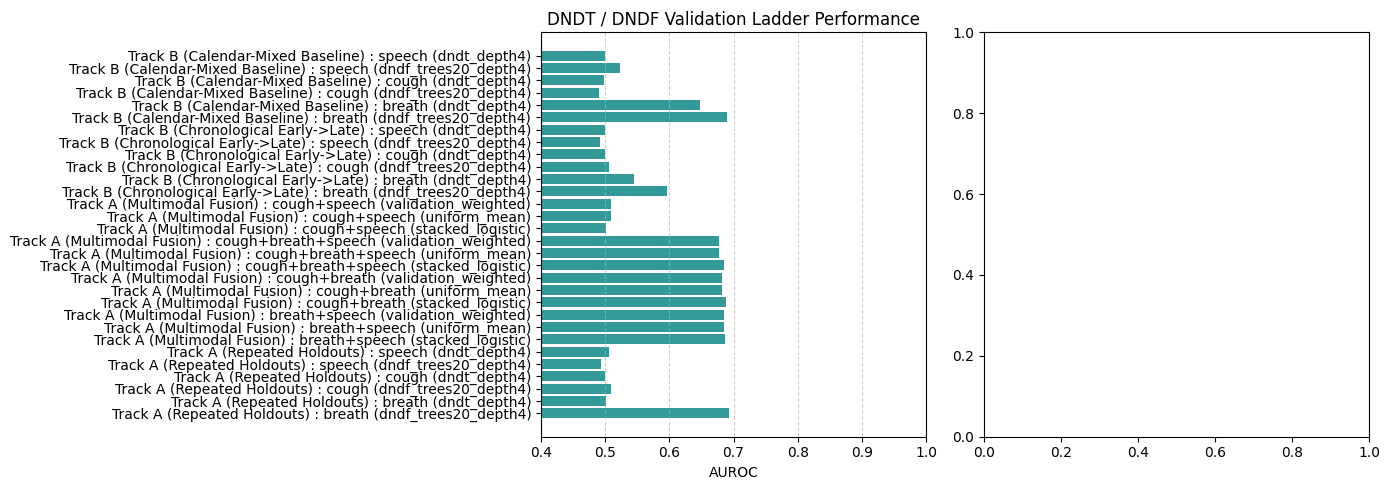

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Summary Bar Chart of Track A vs Track B vs Track C
summary = artifacts.final_summary_table
if not summary.empty:
    axes[0].barh(summary["track"] + " : " + summary["modality"] + " (" + summary["model_name"] + ")", summary["mean_auroc"], color="teal", alpha=0.8)
    axes[0].set_xlim(0.4, 1.0)
    axes[0].set_xlabel("AUROC")
    axes[0].set_title("DNDT / DNDF Validation Ladder Performance")
    axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# 2. Decision Curve Net Benefit
dca = artifacts.dca_summary
if not dca.empty:
    for key, grp in dca.groupby("model_name"):
        axes[1].plot(grp["threshold_probability"], grp["net_benefit_model"], label=f"{key}", lw=2)
    first_grp = list(dca.groupby("model_name"))[0][1]
    axes[1].plot(first_grp["threshold_probability"], first_grp["net_benefit_all"], label="Treat All", linestyle=":", color="gray")
    axes[1].axhline(0, color="black", linestyle="--", label="Treat None")
    axes[1].set_xlabel("Threshold Probability")
    axes[1].set_ylabel("Net Benefit")
    axes[1].set_title("Decision Curve Analysis (DCA)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Exporting Results & Publication Artifacts

In [13]:
print("All DNDT / DNDF artifacts and tables generated successfully:")
print(f" - {output_dir}/dndf_final_validation_summary.csv")
print(f" - {output_dir}/dndf_calibration_summary.csv")
print(f" - {output_dir}/dndf_operating_points.csv")
print(f" - {output_dir}/dndf_decision_curves.csv")
print(f" - {output_dir}/dndf_bootstrap_ci.csv")

All DNDT / DNDF artifacts and tables generated successfully:
 - /kaggle/working/reports/dndf/dndf_final_validation_summary.csv
 - /kaggle/working/reports/dndf/dndf_calibration_summary.csv
 - /kaggle/working/reports/dndf/dndf_operating_points.csv
 - /kaggle/working/reports/dndf/dndf_decision_curves.csv
 - /kaggle/working/reports/dndf/dndf_bootstrap_ci.csv
